# BAB 3 - Exploratory Data Analysis (EDA)
*Exploratory Data Analysis* (EDA) adalah proses kritis dalam *Machine Learning* di mana seorang *data scientist* atau *AI/ML Engineer* membedah,membersihkan, dan menganalisis dataset sebelum membuat model. Tujuannya adalah untuk memahami struktur data, menemukan pola tersembunyi, mendeteksi *outliers*, serta menangani data yang hilang (*missing values*).

---

## A. Pengecekan Awal Struktur Data (First Inspection)
Sebelum membuat grafik visual, langkah pertama adalah memeriksa ukuran data, tipe data tiap kolom, dan mengecek keberadaan *missing values*.

```python
# 1. Cek struktur & tipe data
print("Informasi Dataset:\n", df.info())
# 2. Cek jumlah missing values
print("Jumlah Missing Values:\n", df.isnull().sum())
# 3. Cek ringkasan statistik
print("Statistik Deskriptif:\n", df.describe())
```

---

## B. Analisis Univariat
Analisis ini berfokus pada **satu variabel tunggal** dalam satu waktu untuk melihat distribusi dan karakteristik fiturnya
* **Fitur Kategorikal:** Diperiksa menggunakan `sns.countplot()` untuk melihat frekuensi tiap kategori.
* **Fitur Numerikal:** Diperiksa menggunakan `sns.histplot()` atau `sns.boxplot()` untuk melihat sebaran nilai dan potensi *outliners*

    ```python
    # Cek sebaran variabel target "Selamat"
    sns.countplot(data=df, x='Selamat', palette='pastel', ax=ax[0])
    # Cek sebaran fitur Tarif_Tiket"
    sns.histplot(data=df, x='Tarif_Tiket', kde=True, color='teal', ax=ax[1])
    ```

---

# C. Analisis Bivariat
Analisis ini dilakukan dengan **menganalisis hubungan antara dua variabel secara bersamaan** (antara fitur pendukung dan variabel target)
* **Kategorikal vs Kategorikal:** Menghubungkan variabel menggunakan `sns.countplot()` dengan parameter `hue`
* **Numerikal vs Kategorikal:** Menggunakan `sns.boxplot()` untuk membandungkan nilai numerik antar kelompok target

    ```python
    # Bivariat 1: Kelas Tiket vs Status Selamat
    sns.countplot(data=df, x='Kelas_Tiket', hue='Selamat', palette='Set1', ax=ax[0])
    # Bivariat 2: Tarif Tiket vs Status Selamat
    sns.boxplot(data=df, x='Selamat', y='Tarif_Tiket', palette='Set2', ax=ax[1])
    ```

---

# D. Analisis Multivariat
Analisis ini dilakukan dengan **menganalisis tiga atau lebih variabel** untuk menemukan interaksi dan pola kompleks
* Scatter plot dikombinasikan dengan warna (`hue`) dan bentuk *market* (`style`) untuk menyatukan banyak fitur dalam satu grafik

    ```python
    # Multivariat: Usia vs Tarif Tiket dipisah berdasarkan Status Selamat (hue) dan Kelas Tiket (style)
    sns.scatterplot(data=df, x='Usia', y='Tarif_Tiket', hue='Selamat', style='Kelas_Tiket', s=100, ax=ax)
    ```

---

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Dataset
np.random.seed(42)
df = pd.DataFrame({
    'Usia': np.random.choice([22, 38, 26, 35, np.nan, 54, 2, 27, 14, np.nan], 100),
    'Tarif_Tiket': np.random.uniform(10, 500, 100),
    'Kelas_Tiket': np.random.choice(['First', 'Second', 'Third'], 100),
    'Selamat': np.random.choice([0, 1], 100) # 0 = Tidak, 1 = Ya (Target Variable)
})

C:\Users\asus\AppData\Local\Temp\ipykernel_16488\871624122.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Selamat", palette="pastel", ax=ax1)


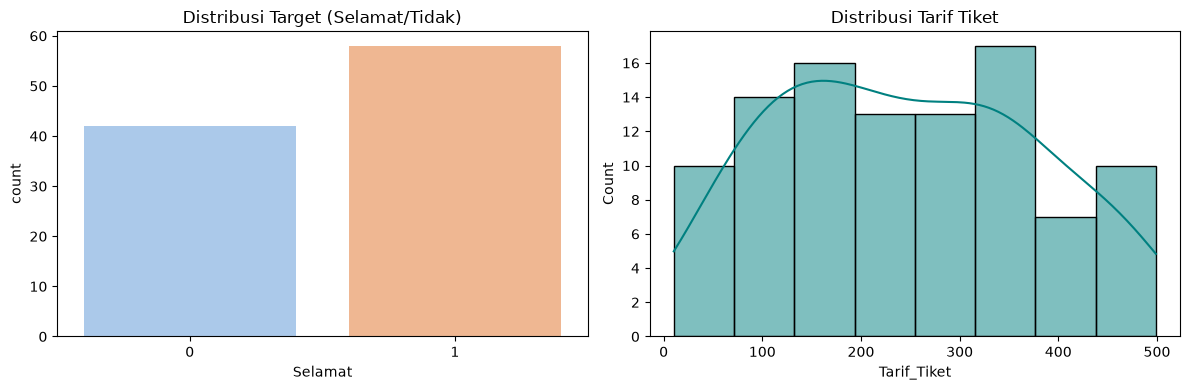

In [4]:
# Analisis Univariat
# membedah variabel secara terpisah -> untuk melihat distribusi dan karakteristik pada fitur

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Univariat Kategorikal
# .countplot()
sns.countplot(data=df, x="Selamat", palette="pastel", ax=ax1)
ax1.set_title("Distribusi Target (Selamat/Tidak)")

# Univariat Numerikal
# .histplot() atau boxplot()
sns.histplot(data=df, x="Tarif_Tiket", kde=True, color="teal", ax=ax2)
ax2.set_title("Distribusi Tarif Tiket")

plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_16488\951570020.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Selamat', y='Tarif_Tiket', palette='Set2', ax=ax[1])


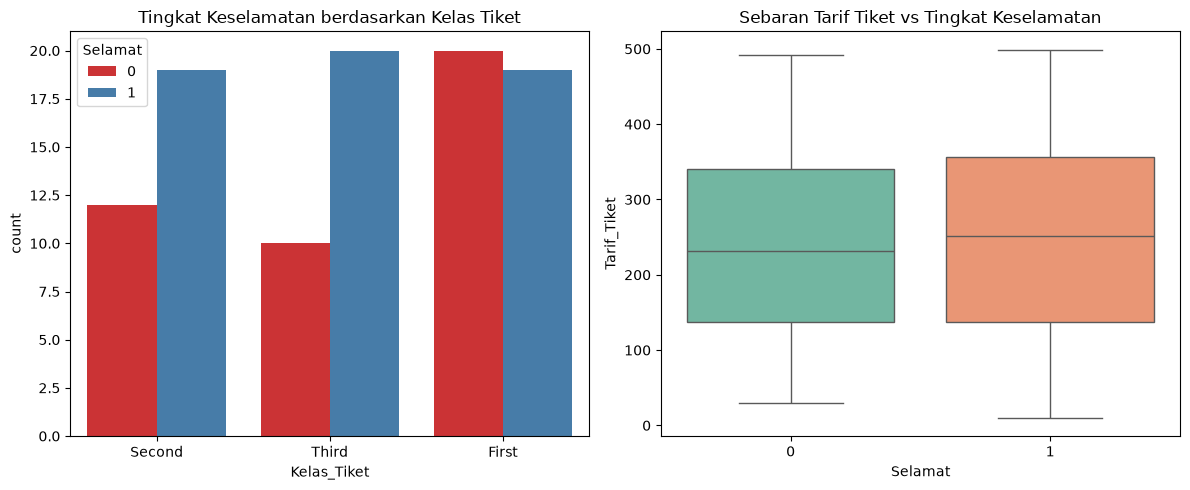

In [5]:
# Analisis Bivariat
# menghubungkan 2 variabel sekaligus untuk melihat fitur pendukung dengan fitur target
# untuk melihat fitur mana yang memiliki pengaruh besar

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Bivariat 1: Apakah Kelas Tiket mempengaruhi tingkat Keselamatan?
sns.countplot(data=df, x='Kelas_Tiket', hue='Selamat', palette='Set1', ax=ax[0])
ax[0].set_title('Tingkat Keselamatan berdasarkan Kelas Tiket')

# Bivariat 2: Apakah orang yang membayar Tarif Tiket lebih mahal punya peluang selamat lebih tinggi?
sns.boxplot(data=df, x='Selamat', y='Tarif_Tiket', palette='Set2', ax=ax[1])
ax[1].set_title('Sebaran Tarif Tiket vs Tingkat Keselamatan')

plt.tight_layout()
plt.show()

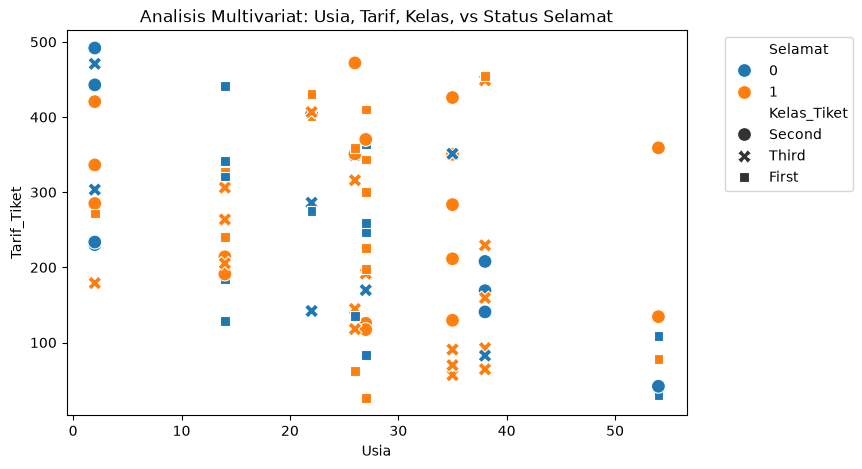

In [ ]:
# Analisis Multivariat
# menggabungkan 2 atau lebih variabel untuk menemukan pola tersembunyi

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x='Usia', y='Tarif_Tiket', hue='Selamat', style='Kelas_Tiket', s=100, ax=ax)
ax.set_title('Analisis Multivariat: Usia, Tarif, Kelas, vs Status Selamat')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Menaruh legend di luar plot agar rapi
plt.show()